# Mass-spring-damper benchmark: adaptive delayed-acceptance MCMC vs. baselines

This notebook is a guided walkthrough of the mass-spring-damper inverse problem used
to benchmark four inference strategies. It is meant to be read top to bottom by
someone unfamiliar with the code, and each figure-producing cell can be edited
in place to change styling, subsets of methods shown, etc.

**The physical problem.** A mass-spring-damper released from rest, `m*x'' + c*x' +
k*x = 0`, `x(0)=x0`, `x'(0)=0`. Mass `m` is fixed/known; the unknowns are stiffness
`k` and damping `c` (see `msd.py` for why mass is fixed: with all three free, only
the natural frequency and damping ratio are identifiable from a single trajectory,
leaving a near-flat ridge in parameter space).

**The four methods being compared** (implemented in `msd_methods.py`):

1. **HF-only Metropolis-Hastings** -- ground-truth reference and the "standard
   single-stage MCMC" baseline. Every step calls the expensive high-fidelity (HF)
   forward model.
2. **Pretrained surrogate + frozen MH** -- a POD-GP surrogate trained *offline only*
   (greedy max-variance active learning, stopping once its own predictive
   uncertainty is below a target), then frozen and used as if it were exact. Matches
   the "Pretrained Model" arm in Riccius et al. (2025).
3. **Riccius-style online active learning** -- the surrogate is substituted directly
   for the likelihood and refined online via an uncertainty threshold, but with *no*
   delayed-acceptance correction step. Matches Algorithm 1 in Riccius et al. (2025),
   "Integration of Active Learning and MCMC Sampling for Efficient Bayesian
   Calibration of Mechanical Properties".
4. **Ours: adaptive delayed-acceptance MCMC with a freeze-to-production stage** --
   the surrogate is refined online during an adaptive phase, guided by the MCMC
   path; once its accuracy stabilizes, it is frozen and a standard delayed-acceptance
   (DA) chain generates the production samples, which carry the DA stationarity
   guarantee (unlike methods 2 and 3).

Methods 2-4 share the same POD-GP surrogate class and the same adaptive
random-walk Metropolis proposal; only the *learning/correction strategy* differs,
so differences between them isolate that strategy's effect rather than surrogate
choice or proposal tuning.

**Two comparisons, not one -- and why `pretrained`'s role changes between them.**
Comparing `pretrained`'s frozen, uncorrected posterior directly against `ours`'s
DA-corrected posterior is not the comparison it looks like: DA-correction removing
surrogate bias is classical delayed-acceptance theory, not this paper's contribution,
so that comparison would just demonstrate DA works, not that `ours`'s *training
strategy* (online, MCMC-path-guided) is better than `pretrained`'s (offline, global
greedy active learning). This notebook therefore keeps the two questions separate:

- **Training-cost comparison** (section 5c): `ours`'s online adaptive phase vs.
  `pretrained`'s offline active-learning procedure, both run only to their own
  convergence criterion, no downstream MCMC on either side -- isolates *training
  strategy* cost, with nothing about posterior correction involved.
- **Posterior-accuracy comparison** (section 5, convergence-driven): `hf_only`,
  `online_active`, and **`ours` only** -- `pretrained` is deliberately excluded here
  (not just from the plots: its expensive replicate loop is never even run), since a
  frozen/uncorrected-vs-DA-corrected posterior comparison wouldn't isolate anything
  this paper claims. `online_active` (Riccius-style, no DA) stays in this comparison
  on purpose: it shows that *even with continual online refinement*, omitting the DA
  correction step still leaves you targeting a biased surrogate posterior, not the
  true one -- a genuinely different, complementary point from the training-cost one.

Sections 1-4 use a single, fixed offline-design size `N_INIT` and a single problem
instance/seed, as a fast, illustrative preview (including `pretrained`'s posterior,
shown there for reference/exploration only -- not a paper claim). Section 5
(single-seed) and section 6 (the actual `--n-seeds 25` sweep, `run_sweep_convergence_
driven.py`) are where the real comparisons live. `N_INIT`/`POD_RANK` are fixed module
constants now (not swept), chosen via `select_pod_rank_and_seed_design` -- see
`msd_methods.py`'s comments on those constants for the full reasoning (in short:
`POD_RANK` needs a large, stable sample to read the spectrum off; `N_INIT` needs to
stay small enough that active learning is actually necessary, which pulls in the
opposite direction, so the two were picked from separate samples).

In [1]:
from __future__ import annotations

import json

import matplotlib.pyplot as plt
import numpy as np
from msd_methods import (
    BURN_IN,
    GAMMA_THRESHOLD,
    KERNEL,
    MAX_ADAPT_COARSE_EVALS,
    N_COARSE_EVALS,
    N_INIT,
    N_REF_ITERATIONS,
    PARAM_NAMES,
    POD_RANK,
    REF_BURN_IN,
    RESULTS_DIR,
    build_initial_surrogate,
    build_problem,
    effective_burn_in,
    ours_coarse_eval_units,
    ours_cumulative_coarse_evals,
    ours_full_resolution_trace,
    ours_multichain_trace,
    print_convergence_driven_table,
    print_convergence_table,
    run_convergence_check,
    run_convergence_driven_comparison,
    run_hf_only,
    run_online_active,
    run_ours,
    run_pretrained,
    run_training_cost_comparison,
    summarize,
)

from gp_active_mcmc.diagnostics import plot_prediction_at_theta
from gp_active_mcmc.utils.rng import set_seed

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)


def save_fig(fig, name: str, n_init: int) -> None:
    """Save a figure to RESULTS_DIR/figures/{name}_n_init_{n_init}.png, at the
    savefig.dpi set in the rcParams below, and print the path (relative to
    examples/toy_problem/) so it's easy to find without leaving the notebook."""
    path = FIGURES_DIR / f"{name}_n_init_{n_init}.png"
    fig.savefig(path, bbox_inches="tight")
    print(f"  saved {path.relative_to(RESULTS_DIR.parent)}")


N_CHAINS = 5  # used for every convergence check below
N_COARSE_EVALS_LONG = 1000  # long horizon for the convergence check specifically, so R-hat has room to resolve

# Convergence-driven comparison (section 5): chunk size and safety cap, both in
# coarse-evaluation units (uniform currency across all four methods -- see
# run_until_rhat_converged's docstring in msd_methods.py). rhat_threshold=1.01 and
# min_ess=400 together (not R-hat alone) are what find_burn_in_via_rhat requires
# before declaring a method converged -- see its docstring for why R-hat alone can
# pass "by luck" on a too-small sample (this bit `ours` at low n_init, where its
# frozen production rows are each expensive relative to chunk_size). These match
# run_sweep_convergence_driven.py's defaults, so the single-seed preview here and the
# 25-seed sweep loaded in section 6 are directly comparable.
CONVERGENCE_DRIVEN_CHUNK_SIZE = 500
CONVERGENCE_DRIVEN_MAX_TOTAL_COARSE_EVALS = 10_000
CONVERGENCE_DRIVEN_RHAT_THRESHOLD = 1.01
CONVERGENCE_DRIVEN_MIN_ESS = 400

# Paper-style figure defaults: applied once here, inherited by every plot below.
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.axisbelow": True,
})

# "hf_only_matched" (section 4's single quick-look chain) and "hf_only" (the method-name
# key used by run_convergence_check/run_convergence_driven_comparison's multi-chain
# dicts) are kept as separate keys since they come from different call sites, but map
# to the same styling.
METHOD_COLORS = {
    "hf_only_matched": "0.35",
    "hf_only": "0.35",
    "pretrained": "tab:red",
    "online_active": "tab:orange",
    "ours": "tab:blue",
}
METHOD_MARKERS = {"pretrained": "s", "online_active": "^", "ours": "o"}
METHOD_LABELS = {
    "hf_only_matched": "MH with HF",
    "hf_only": "MH with HF",
    "pretrained": "Pretrained (offline)",
    "online_active": "Riccius-style online",
    "ours": "Ours (adaptive DA + freeze)",
}
# Section 4 (illustrative preview) shows all three surrogate-based methods, including
# `pretrained`, for reference. Section 5/6 (the actual posterior-accuracy comparison)
# deliberately exclude `pretrained` -- see cell 44ec13f4's markdown for why -- so they
# use METHOD_ORDER_ACCURACY instead.
METHOD_ORDER = ("pretrained", "online_active", "ours")
METHOD_ORDER_ACCURACY = ("online_active", "ours")
TRACE_METHOD_ORDER = ("hf_only_matched", "pretrained", "online_active", "ours")
TRACE_METHOD_ORDER_MULTICHAIN = ("hf_only", "pretrained", "online_active", "ours")
TRACE_METHOD_ORDER_MULTICHAIN_ACCURACY = ("hf_only", "online_active", "ours")

# Shared colors for the LF-step/HF-call coloring used by the trace plots.
LF_COLOR = "tab:blue"
HF_COLOR = "tab:red"


## 1. Problem setup

A single problem instance: fixed `theta_true` (drawn from the prior), a noisy
synthetic observation. Edit `PROBLEM_SEED` below and re-run the notebook to explore
a different instance. This does not depend on `n_init`, so it's computed once.

theta_true: {'k': 58.21770123928726, 'c': 2.809360141291611}


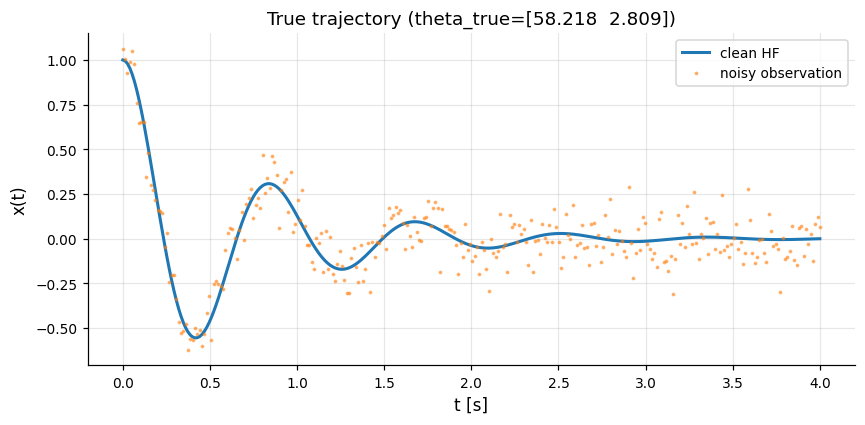

In [2]:
PROBLEM_SEED = 0
problem = build_problem(problem_seed=PROBLEM_SEED, sigma_obs=0.1)
print("theta_true:", dict(zip(PARAM_NAMES, problem.theta_true.tolist(), strict=True)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(problem.t, problem.hf_forward(problem.theta_true), lw=2, label="clean HF")
ax.plot(problem.t, problem.y_obs, ".", ms=3, alpha=0.5, label="noisy observation")
ax.set_xlabel("t [s]")
ax.set_ylabel("x(t)")
ax.legend()
ax.set_title(f"True trajectory (theta_true={np.round(problem.theta_true, 3)})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "true_trajectory.png", bbox_inches="tight")


## 2. HF-only reference chains

Also n_init-independent: a long, well-converged chain used as ground truth for
accuracy comparisons, plus a budget-matched (N=N_COARSE_EVALS) chain used both as the
"standard single-stage MCMC" baseline and as the trace-plot comparison row.

In [3]:
chain_ref = run_hf_only(problem, iterations=N_REF_ITERATIONS, seed=10_000)
ref_mean = chain_ref.burn_in(REF_BURN_IN).samples.mean(axis=0)
print("hf_only_reference:", summarize(chain_ref, problem, burn_in=REF_BURN_IN))

chain_hf_matched = run_hf_only(problem, iterations=N_COARSE_EVALS, seed=11_000)
print("hf_only_matched:", summarize(chain_hf_matched, problem, burn_in=BURN_IN, reference_mean=ref_mean))


Sampling chain 1/1



  0%|          | 0/3000 [00:00<?, ?it/s]


Running chain, α = 1.00:   0%|          | 0/3000 [00:00<?, ?it/s]


Running chain, α = 0.50:   0%|          | 0/3000 [00:00<?, ?it/s]


Running chain, α = 0.67:   0%|          | 0/3000 [00:00<?, ?it/s]

...


Running chain, α = 0.29:  96%|█████████▌| 961/1000 [00:02<00:00, 407.91it/s]


Running chain, α = 0.30:  96%|█████████▌| 961/1000 [00:02<00:00, 407.91it/s]


Running chain, α = 0.29:  96%|█████████▌| 961/1000 [00:02<00:00, 407.91it/s]


Running chain, α = 0.29: 100%|██████████| 1000/1000 [00:02<00:00, 385.39it/s]

hf_only_matched: {'n_steps': 1001, 'posterior_mean': [58.94933911441337, 2.8101008303706623], 'posterior_std': [0.6822443864195283, 0.10932170810651015], 'rmse_to_truth': 0.8335690339817085, 'n_offline_hf': 0, 'n_hf_calls_online': 1001, 'n_hf_calls': 1001, 'hf_call_fraction': 1.0, 'mean_abs_dev_from_reference': [0.04902956146456461, 0.007515562126889197]}


## 3. Helper functions

Defined once, then invoked for each `n_init` in `N_INIT_SETTINGS` in the loop below.

In [4]:
def run_all_methods(problem, *, n_init: int, pod_rank: int, seed_offset: int):
    """Build the initial surrogate and run all four surrogate-based methods."""
    seed_surrogate, seed_X, seed_Y = build_initial_surrogate(
        problem, set_seed(1_000 + seed_offset), n_init=n_init, pod_rank=pod_rank, kernel=KERNEL
    )

    chain_ours, meta_ours, surrogate_ours = run_ours(
        problem,
        surrogate=seed_surrogate,
        gamma_threshold=GAMMA_THRESHOLD,
        n_coarse_evals=N_COARSE_EVALS,
        max_adapt_coarse_evals=MAX_ADAPT_COARSE_EVALS,
        seed=12_000 + seed_offset,
    )
    chain_pretrained, n_hf_pretrained, surrogate_pretrained = run_pretrained(
        problem,
        seed_X=seed_X,
        seed_Y=seed_Y,
        gamma_threshold=GAMMA_THRESHOLD,
        pod_rank=pod_rank,
        kernel=KERNEL,
        iterations=N_COARSE_EVALS,
        seed=13_000 + seed_offset,
    )
    chain_online, surrogate_online = run_online_active(
        problem,
        surrogate=seed_surrogate,
        gamma_threshold=GAMMA_THRESHOLD,
        iterations=N_COARSE_EVALS,
        seed=14_000 + seed_offset,
    )

    return {
        "seed_surrogate": seed_surrogate,
        "seed_X": seed_X,
        "seed_Y": seed_Y,
        "chains": {"pretrained": chain_pretrained, "online_active": chain_online, "ours": chain_ours},
        "surrogates_after": {
            "pretrained": surrogate_pretrained, "online_active": surrogate_online, "ours": surrogate_ours
        },
        "n_hf_pretrained": n_hf_pretrained,
        "meta_ours": meta_ours,
    }


def print_summary_table(problem, n_init, res):
    # `ours` burn-in must discard the whole (non-stationary) adaptive phase, not the
    # shared BURN_IN=100 -- see effective_burn_in()'s docstring for why. `ours` also
    # needs `n_coarse_eval_units` for its HF-call-fraction denominator, since its chain
    # rows aren't one-coarse-eval-per-row throughout (see ours_coarse_eval_units()).
    summary = {
        "ours": summarize(
            res["chains"]["ours"], problem, burn_in=effective_burn_in("ours", meta_ours=res["meta_ours"]),
            reference_mean=ref_mean, n_offline_hf=n_init,
            n_coarse_eval_units=ours_coarse_eval_units(res["meta_ours"]),
        ),
        "pretrained": summarize(
            res["chains"]["pretrained"], problem, burn_in=BURN_IN, reference_mean=ref_mean,
            n_offline_hf=res["n_hf_pretrained"],
        ),
        "online_active": summarize(
            res["chains"]["online_active"], problem, burn_in=BURN_IN, reference_mean=ref_mean, n_offline_hf=n_init
        ),
    }
    for name, s in summary.items():
        print(
            f"{name:<16} hf_total={s['n_hf_calls']:>5} hf_frac={s['hf_call_fraction']:.3f}  "
            f"rmse={s['rmse_to_truth']:.4f}  mean={np.round(s['posterior_mean'], 3)}"
        )
    (RESULTS_DIR / f"notebook_summary_n_init_{n_init}.json").write_text(json.dumps(summary, indent=2))
    return summary


def plot_posterior_comparison(problem, n_init, chain_ref, chains, meta_ours):
    # Same fix as print_summary_table: `ours` must use its own adaptive-phase length as
    # burn-in, not the shared BURN_IN, or the scatter mixes in non-stationary samples.
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ref_post = chain_ref.burn_in(REF_BURN_IN).samples
    ax.hexbin(ref_post[:, 0], ref_post[:, 1], gridsize=40, cmap="Greys", mincnt=1, alpha=0.55, zorder=1)
    for name in METHOD_ORDER:
        b = effective_burn_in(name, meta_ours=meta_ours) if name == "ours" else BURN_IN
        post = chains[name].burn_in(b).samples
        ax.scatter(
            post[:, 0], post[:, 1], s=26, alpha=0.55, facecolors="none", edgecolors=METHOD_COLORS[name],
            marker=METHOD_MARKERS[name], linewidths=1.0, label=METHOD_LABELS[name], zorder=3,
        )
    ax.scatter(*problem.theta_true, s=180, c="k", marker="*", zorder=5, label=r"$\theta_{\mathrm{true}}$")
    ax.set_xlabel(PARAM_NAMES[0])
    ax.set_ylabel(PARAM_NAMES[1])
    ax.set_title(f"Posterior comparison (n_init={n_init})")
    ax.legend(fontsize=9)
    fig.tight_layout()
    return fig


def combined_hf_fraction_curve(
    n_offline: int, used_hf_online: np.ndarray, *, x: np.ndarray | None = None
) -> tuple[np.ndarray, np.ndarray]:
    """Cumulative HF fraction including upfront offline cost (paid "before iteration 1").

    `x` overrides the default x-axis (row index) with an explicit per-row cumulative
    coarse-evaluation count -- needed for `ours` (via `ours_cumulative_coarse_evals`),
    whose rows are one coarse evaluation each only during the adaptive phase; during
    the frozen production phase each row is a whole DA block of several coarse
    evaluations, so row index alone would compress that phase into a misleadingly
    short, steep stretch of the plot. Defaults to `np.arange(1, n+1)`, correct for the
    other three methods (whose rows already are one coarse evaluation each).
    """
    online = used_hf_online.astype(float)
    it = np.arange(1, online.size + 1, dtype=float) if x is None else np.asarray(x, dtype=float)
    cum_hf = n_offline + np.cumsum(online)
    return it, cum_hf / (n_offline + it)


def plot_hf_fraction(n_init, chains, n_hf_pretrained, meta_ours):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    offline_costs = {"pretrained": n_hf_pretrained, "online_active": n_init, "ours": n_init}
    for name in METHOD_ORDER:
        chain = chains[name]
        used_hf = chain.extras.used_hf if chain.extras.used_hf is not None else np.zeros(chain.n_steps, dtype=bool)
        x = ours_cumulative_coarse_evals(meta_ours) if name == "ours" else None
        it, frac = combined_hf_fraction_curve(offline_costs[name], used_hf, x=x)
        ax.plot(it, frac, color=METHOD_COLORS[name], lw=1.8, label=f"{METHOD_LABELS[name]} (offline={offline_costs[name]})")
    ax.set_xlabel("Coarse-evaluation iteration")
    ax.set_ylabel("Cumulative HF fraction\n(offline cost included)")
    ax.set_title(f"HF usage (n_init={n_init})")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=9)
    fig.tight_layout()
    return fig


def _method_full_resolution_trace(name, chain, meta_ours):
    """(x, samples, used_hf) at full temporal resolution for one method's trace.

    For every method except `ours`, `chain` already *is* full resolution (one row per
    coarse evaluation, with its own genuine `used_hf` flag): `hf_only_matched` is
    trivially all-True, `pretrained` is trivially all-False (frozen, never calls HF
    online), `online_active` is a genuine mix. Only `ours` needs reconstruction, via
    `ours_full_resolution_trace`, because its posterior-inference chain
    (`chain_fine_0`) skips the intra-block low-fidelity steps during production.
    """
    if name == "ours":
        return ours_full_resolution_trace(chain, meta_ours)
    x = np.arange(1, chain.n_steps + 1, dtype=float)
    used_hf = chain.extras.used_hf if chain.extras.used_hf is not None else np.zeros(chain.n_steps, dtype=bool)
    return x, chain.samples, used_hf


def make_hf_colored_trace_fig(problem, n_init, trace_chains, meta_ours, burn_ins: dict[str, int], mode: str, title_suffix: str):
    """Trace plot at full temporal resolution, colored by whether each point required
    an HF evaluation (blue = cheap LF/surrogate step, red = expensive HF call).

    Without this, `ours`'s trace (built from `chain_fine_0`, one point per DA block)
    looks like a sparse sequence of big jumps and makes the other methods -- which
    plot *every* coarse step -- look artificially better-mixed by comparison, even
    though `ours` is doing much more (cheap) exploration between each (expensive)
    HF-corrected sample than its trace alone would suggest.

    mode="full": every sample (x in coarse-evaluation-iteration units), with a
    vertical line at each row's own burn-in.
    mode="post_burn_in": only samples after each row's own burn-in (per-method, not a
    single shared offset -- `ours` uses its adaptive-phase length, others use BURN_IN).
    """
    fig, axes = plt.subplots(len(TRACE_METHOD_ORDER), 2, figsize=(11, 2.6 * len(TRACE_METHOD_ORDER)), sharex=False)
    for r, name in enumerate(TRACE_METHOD_ORDER):
        x, samples, used_hf = _method_full_resolution_trace(name, trace_chains[name], meta_ours)
        b = burn_ins[name]
        if mode == "post_burn_in":
            mask = x > b
            x, samples, used_hf = x[mask], samples[mask], used_hf[mask]
        for p in range(2):
            ax = axes[r, p]
            ax.plot(x, samples[:, p], color="0.8", lw=0.5, zorder=1)
            ax.scatter(
                x[~used_hf], samples[~used_hf, p], s=4, color=LF_COLOR, alpha=0.5, zorder=2, label="LF step"
            )
            ax.scatter(
                x[used_hf], samples[used_hf, p], s=16, color=HF_COLOR, alpha=0.9, zorder=3, label="HF call"
            )
            ax.axhline(problem.theta_true[p], color="k", ls="--", lw=1)
            if mode == "full":
                ax.axvline(b, color="tab:green", ls=":", lw=1.5)
            if r == 0:
                ax.set_title(PARAM_NAMES[p])
            if p == 0:
                ax.set_ylabel(METHOD_LABELS.get(name, name), fontsize=9)
            if r == 0 and p == 1:
                ax.legend(fontsize=7, loc="upper right", markerscale=2)
    for p in range(2):
        axes[-1, p].set_xlabel("Coarse-evaluation iteration")
    fig.suptitle(f"Trace plots (LF/HF colored){title_suffix} (n_init={n_init})")
    fig.tight_layout()
    return fig


def plot_surrogate_before_after(problem, n_init, seed_surrogate, surrogates_after):
    fig, axes = plt.subplots(1, len(METHOD_ORDER), figsize=(6 * len(METHOD_ORDER), 4), sharey=True)
    t = problem.t
    y_true = problem.hf_forward(problem.theta_true)
    for a, name in enumerate(METHOD_ORDER):
        ax = axes[a]
        ax.plot(t, problem.y_obs, ".", ms=2, alpha=0.3, color="0.5", label="observations")
        ax.plot(t, y_true, color="k", lw=1.5, label="true profile")

        mean_before, var_before = seed_surrogate.predict(problem.theta_true)
        ax.plot(t, mean_before, color="tab:gray", lw=1.5, label="surrogate (before)")
        ax.fill_between(
            t, mean_before - 2 * np.sqrt(var_before), mean_before + 2 * np.sqrt(var_before),
            color="tab:gray", alpha=0.2,
        )

        mean_after, var_after = surrogates_after[name].predict(problem.theta_true)
        ax.plot(t, mean_after, color=METHOD_COLORS[name], lw=1.5, label="surrogate (after)")
        ax.fill_between(
            t, mean_after - 2 * np.sqrt(var_after), mean_after + 2 * np.sqrt(var_after),
            color=METHOD_COLORS[name], alpha=0.25,
        )

        ax.set_title(METHOD_LABELS[name])
        ax.set_xlabel("t")
        if a == 0:
            ax.set_ylabel("x(t)")
            ax.legend(fontsize=8)
    fig.suptitle(f"Surrogate prediction at theta_true, before vs. after learning (n_init={n_init})")
    fig.tight_layout()
    return fig


def plot_pooled_posterior_comparison(problem, n_init, chain_ref, conv_results, chains_by_method, method_order=METHOD_ORDER):
    """Posterior comparison using the R-hat-validated burn-in and samples pooled across
    all replicate chains -- the "real" version, vs. section 4's single-chain preview
    (which uses a heuristic burn-in and one chain per method).

    `method_order` defaults to showing all three surrogate-based methods (section 4
    style); section 5/6 pass `METHOD_ORDER_ACCURACY` to drop `pretrained` from the
    posterior-accuracy comparison -- see cell 44ec13f4's markdown for why.
    """
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ref_post = chain_ref.burn_in(REF_BURN_IN).samples
    ax.hexbin(ref_post[:, 0], ref_post[:, 1], gridsize=40, cmap="Greys", mincnt=1, alpha=0.55, zorder=1)
    for name in method_order:
        b = conv_results[name]["burn_in"] or 0
        chains = chains_by_method[name]
        pooled = np.concatenate([c.burn_in(b).samples for c in chains], axis=0)
        w2 = conv_results[name]["pooled"].get("wasserstein2_to_reference")
        label = f"{METHOD_LABELS[name]} (burn_in={b}, {len(chains)} chains"
        label += f", W2={w2:.3f})" if w2 is not None else ")"
        ax.scatter(
            pooled[:, 0], pooled[:, 1], s=14, alpha=0.35, facecolors="none", edgecolors=METHOD_COLORS[name],
            marker=METHOD_MARKERS[name], linewidths=0.8, label=label, zorder=3,
        )
    ax.scatter(*problem.theta_true, s=180, c="k", marker="*", zorder=5, label=r"$\theta_{\mathrm{true}}$")
    ax.set_xlabel(PARAM_NAMES[0])
    ax.set_ylabel(PARAM_NAMES[1])
    ax.set_title(f"Pooled posterior, R-hat-validated burn-in (n_init={n_init})")
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# Multi-chain (N_CHAINS-replicate) versions of section 4's per-figure-type plots.
# ---------------------------------------------------------------------------
#
# Section 4's plots (posterior comparison, HF fraction, trace, surrogate before/after)
# each use a single quick-look chain per method. `plot_pooled_posterior_comparison`
# above already has a multi-chain analog for the posterior-comparison plot; the three
# functions below extend the same idea to the other three plot types, so every figure
# type is available at both single-chain (section 4) and N_CHAINS-replicate (section 5)
# resolution. All three take a common `offline_costs_by_method` /
# `surrogates_by_method` shape: `results[name]["pooled"]["n_offline_hf"]` is *always* a
# per-chain list (that's how `pooled_summarize` reports it, whether the underlying
# `n_offline_hf` argument was a scalar or already a list), so
# `{name: r["pooled"]["n_offline_hf"] for name, r in results.items()}` works
# identically for both `run_convergence_check` and `run_convergence_driven_comparison`.
#
# All four take a `method_order`/`trace_method_order` parameter (defaulting to the
# full three-method set) so section 5/6 can pass the `pretrained`-excluding variants
# (`METHOD_ORDER_ACCURACY`/`TRACE_METHOD_ORDER_MULTICHAIN_ACCURACY`) -- see cell
# 44ec13f4's markdown for why the posterior-accuracy comparison excludes `pretrained`.


def prepare_multichain_traces_section5b(chains_by_method, results, method_order=METHOD_ORDER):
    """Per-chain (x, samples, used_hf) triples for every method, from
    `run_convergence_driven_comparison`'s output, plus each method's R-hat-validated
    burn-in converted into the same x-axis (coarse-evaluation-iteration) units as its
    trace -- needed by `make_hf_colored_trace_fig_multichain`'s vertical burn-in line /
    post-burn-in filtering. `ours` is at DA-block resolution during production (see
    `ours_multichain_trace`'s docstring for why: the chunked replicate runs don't
    request a per-chunk diagnostic chain, unlike `run_ours`), not full LF resolution
    the way section 5's version is.

    `"hf_only"` is always included (it's the reference method, never excluded by
    `method_order`); `"ours"` is handled separately below regardless of `method_order`
    (it's never excluded either -- only `"pretrained"` ever is, via
    `METHOD_ORDER_ACCURACY`).
    """
    traces = {}
    burn_ins_x = {}
    secondary_methods = [m for m in method_order if m != "ours"]
    for name in ("hf_only", *secondary_methods):
        traces[name] = [
            (
                np.arange(1, c.n_steps + 1, dtype=float),
                c.samples,
                c.extras.used_hf if c.extras.used_hf is not None else np.zeros(c.n_steps, dtype=bool),
            )
            for c in chains_by_method[name]
        ]
        # Row index *is* the x-axis for these methods, so the R-hat-validated burn-in
        # (a row count) is already in x units.
        burn_ins_x[name] = results[name]["burn_in"] or 0
    adapt_metas = results["ours"]["adapt_metas"]
    coarse_evals_per_chain = results["ours"]["coarse_evals_per_chain"]
    ours_traces = []
    frozen_rate = 1
    for adapt_chain, adapt_meta, production_chain, production_cost in zip(
        chains_by_method["ours_adapt"], adapt_metas, chains_by_method["ours"], coarse_evals_per_chain, strict=True
    ):
        # frozen_rate is exactly production_cost / (n genuine new production rows):
        # subsampling_rate is constant throughout production (frozen), and
        # coarse_evals_per_chain already sums iterations*subsampling_rate per round --
        # see _run_chunk's docstring in msd_methods.py.
        frozen_rate = production_cost // (production_chain.n_steps - 1) if production_chain.n_steps > 1 else 1
        ours_traces.append(ours_multichain_trace(adapt_chain, adapt_meta, production_chain, frozen_rate))
    traces["ours"] = ours_traces
    # `chains_by_method["ours"]` (what `find_burn_in_via_rhat` searched over for
    # `results["ours"]["burn_in"]`) is production-only, block resolution -- row 0 is
    # the *first* production block, unlike section 5's mixed-granularity chain.
    # Convert that block count into the trace's x units the same way
    # `ours_multichain_trace`'s `production_x` does: offset by the (shared) adaptive
    # phase's coarse-eval cost, scaled by the (shared) frozen subsampling rate --
    # `frozen_rate` is identical across replicates here since they all come from one
    # shared adaptive phase (see this function's docstring / the caller's
    # `run_convergence_driven_comparison`).
    n_adapt_coarse_evals = int(adapt_metas[0]["adapt_coarse_evals_used"])
    ours_burn_in_row = results["ours"]["burn_in"] or 0
    burn_ins_x["ours"] = n_adapt_coarse_evals + frozen_rate * ours_burn_in_row
    return traces, burn_ins_x


def plot_hf_fraction_multichain(n_init, traces, offline_costs_by_method, title_suffix="", method_order=METHOD_ORDER):
    """Overlay every replicate chain's cumulative HF-fraction curve per method (thin,
    semi-transparent lines) -- shows both the typical cost and how much it varies
    across independent replicates, which a single chain can't show."""
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for name in method_order:
        chain_traces = traces[name]
        offline_costs = offline_costs_by_method[name]
        for i, (x, _samples, used_hf) in enumerate(chain_traces):
            it, frac = combined_hf_fraction_curve(offline_costs[i], used_hf, x=x)
            ax.plot(
                it, frac, color=METHOD_COLORS[name], lw=1.0, alpha=0.45,
                label=f"{METHOD_LABELS[name]} ({len(chain_traces)} chains)" if i == 0 else None,
            )
    ax.set_xlabel("Coarse-evaluation iteration")
    ax.set_ylabel("Cumulative HF fraction\n(offline cost included)")
    ax.set_title(f"HF usage across replicate chains{title_suffix} (n_init={n_init})")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=9)
    fig.tight_layout()
    return fig


def make_hf_colored_trace_fig_multichain(
    problem, n_init, traces, burn_ins: dict[str, float], mode: str, title_suffix: str = "",
    trace_method_order=TRACE_METHOD_ORDER_MULTICHAIN,
):
    """Overlay every replicate chain's LF/HF-colored trace per method/param (faint
    points so `N_CHAINS` overlapping chains stay legible) -- the multi-chain analog of
    `make_hf_colored_trace_fig`, showing the aggregate LF/HF pattern across replicates
    rather than one chain's specific path.

    `burn_ins`: one value per method (in the same x-axis units as its trace, from
    `prepare_multichain_traces_section5b`) -- shared across a method's replicates,
    matching how R-hat's convergence check itself assumes/produces a single common
    burn-in across the same-target chains.

    mode="full": every sample, with a vertical line at each method's burn-in.
    mode="post_burn_in": only samples after each method's own burn-in.
    """
    fig, axes = plt.subplots(
        len(trace_method_order), 2, figsize=(11, 2.6 * len(trace_method_order)), sharex=False
    )
    for r, name in enumerate(trace_method_order):
        chain_traces = traces[name]
        b = burn_ins[name]
        for p in range(2):
            ax = axes[r, p]
            for i, (x, samples, used_hf) in enumerate(chain_traces):
                if mode == "post_burn_in":
                    mask = x > b
                    x, samples, used_hf = x[mask], samples[mask], used_hf[mask]
                ax.plot(x, samples[:, p], color="0.85", lw=0.3, zorder=1)
                ax.scatter(
                    x[~used_hf], samples[~used_hf, p], s=3, color=LF_COLOR, alpha=0.35, zorder=2,
                    label="LF step" if (i == 0 and r == 0 and p == 1) else None,
                )
                ax.scatter(
                    x[used_hf], samples[used_hf, p], s=10, color=HF_COLOR, alpha=0.6, zorder=3,
                    label="HF call" if (i == 0 and r == 0 and p == 1) else None,
                )
            ax.axhline(problem.theta_true[p], color="k", ls="--", lw=1)
            if mode == "full":
                ax.axvline(b, color="tab:green", ls=":", lw=1.5)
            if r == 0:
                ax.set_title(PARAM_NAMES[p])
            if p == 0:
                ax.set_ylabel(f"{METHOD_LABELS.get(name, name)}\n({len(chain_traces)} chains)", fontsize=9)
            if r == 0 and p == 1:
                ax.legend(fontsize=7, loc="upper right", markerscale=2)
    for p in range(2):
        axes[-1, p].set_xlabel("Coarse-evaluation iteration")
    fig.suptitle(f"Trace plots across replicate chains (LF/HF colored){title_suffix} (n_init={n_init})")
    fig.tight_layout()
    return fig


def plot_surrogate_before_after_multichain(
    problem, n_init, seed_surrogate, surrogates_by_method, title_suffix="", method_order=METHOD_ORDER
):
    """Overlay every replicate's trained ('after') surrogate prediction at theta_true,
    per method -- shows how consistent the learned surrogate is across independent
    replicate runs (e.g. `pretrained`'s offline design differs every replicate), not
    just a single one."""
    fig, axes = plt.subplots(1, len(method_order), figsize=(6 * len(method_order), 4), sharey=True)
    if len(method_order) == 1:
        axes = [axes]
    t = problem.t
    y_true = problem.hf_forward(problem.theta_true)
    mean_before, var_before = seed_surrogate.predict(problem.theta_true)
    for a, name in enumerate(method_order):
        ax = axes[a]
        ax.plot(t, problem.y_obs, ".", ms=2, alpha=0.3, color="0.5", label="observations")
        ax.plot(t, y_true, color="k", lw=1.5, label="true profile")
        ax.plot(t, mean_before, color="tab:gray", lw=1.2, ls=":", label="surrogate (before)")

        surrogates_after = surrogates_by_method[name]
        for i, surrogate in enumerate(surrogates_after):
            mean_after, _var_after = surrogate.predict(problem.theta_true)
            ax.plot(
                t, mean_after, color=METHOD_COLORS[name], lw=1.0, alpha=0.5,
                label="surrogate (after)" if i == 0 else None,
            )

        ax.set_title(f"{METHOD_LABELS[name]} ({len(surrogates_after)} replicates)")
        ax.set_xlabel("t")
        if a == 0:
            ax.set_ylabel("x(t)")
            ax.legend(fontsize=8)
    fig.suptitle(f"Surrogate prediction at theta_true across replicates{title_suffix} (n_init={n_init})")
    fig.tight_layout()
    return fig


## 4. Quick-look preview at the fixed `N_INIT`

Runs all four methods once, at `N_INIT`, and shows the summary table plus the
posterior comparison / HF-usage / trace / surrogate-before-after figures. This is a
fast, single-chain, single-seed preview -- **illustrative only**, including
`pretrained`'s posterior shown here for reference/exploration (see cell 44ec13f4's
markdown for why that specific comparison isn't a paper claim). The slow multi-chain
R-hat/ESS convergence check (the actual posterior-accuracy comparison) is in section 5
below, so this preview doesn't have to wait on it.


 /Users/filippozacchei/COde/MFDA_ActiveLearning/.venv/lib/python3.10/site-packages/tinyDA/sampler.py:114: UserWarning: subsampling_rate has been deprecated in favour of subchain_length.


Sampling chain 1/1



  0%|          | 0/10 [00:00<?, ?it/s]


Running chain, α_c = 1.000, α_f = 1.00:   0%|          | 0/10 [00:00<?, ?it/s]


Running chain, α_c = 1.000, α_f = 1.00:  10%|█         | 1/10 [00:00<00:03,  2.34it/s]

...


Running chain, α = 0.31: 100%|██████████| 1000/1000 [00:16<00:00, 60.83it/s]


--- summary (n_init=20) ---
ours             hf_total=   70 hf_frac=0.069  rmse=0.9142  mean=[58.84   2.759]
pretrained       hf_total=   95 hf_frac=0.087  rmse=0.9370  mean=[58.975  2.789]
online_active    hf_total=   25 hf_frac=0.024  rmse=0.8963  mean=[58.853  2.798]


  saved results/figures/posterior_comparison_n_init_20.png
  saved results/figures/hf_fraction_n_init_20.png


  saved results/figures/trace_full_n_init_20.png


  saved results/figures/trace_post_burn_in_n_init_20.png
  saved results/figures/surrogate_before_after_n_init_20.png


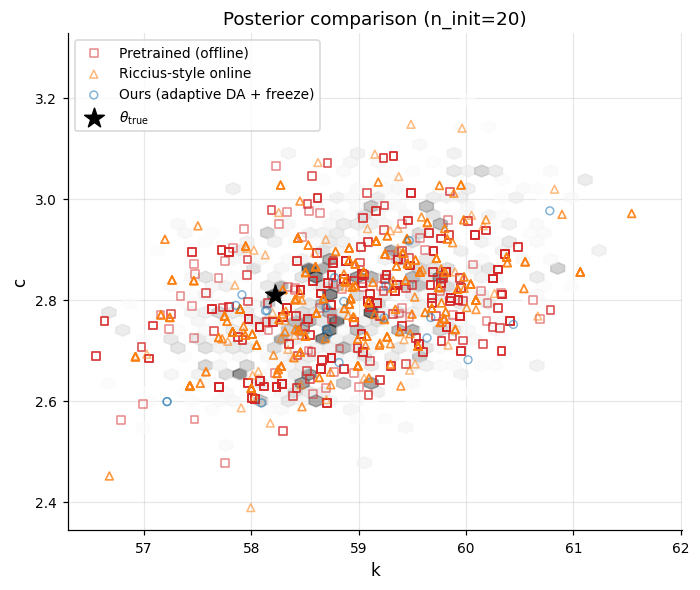

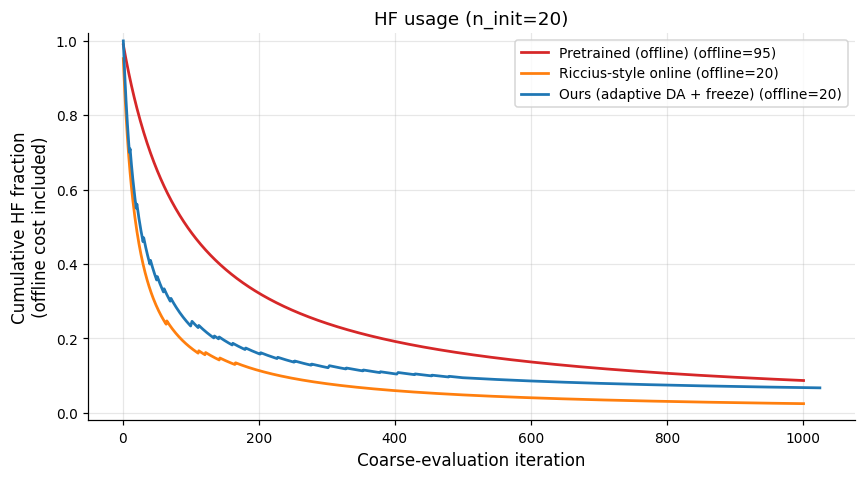

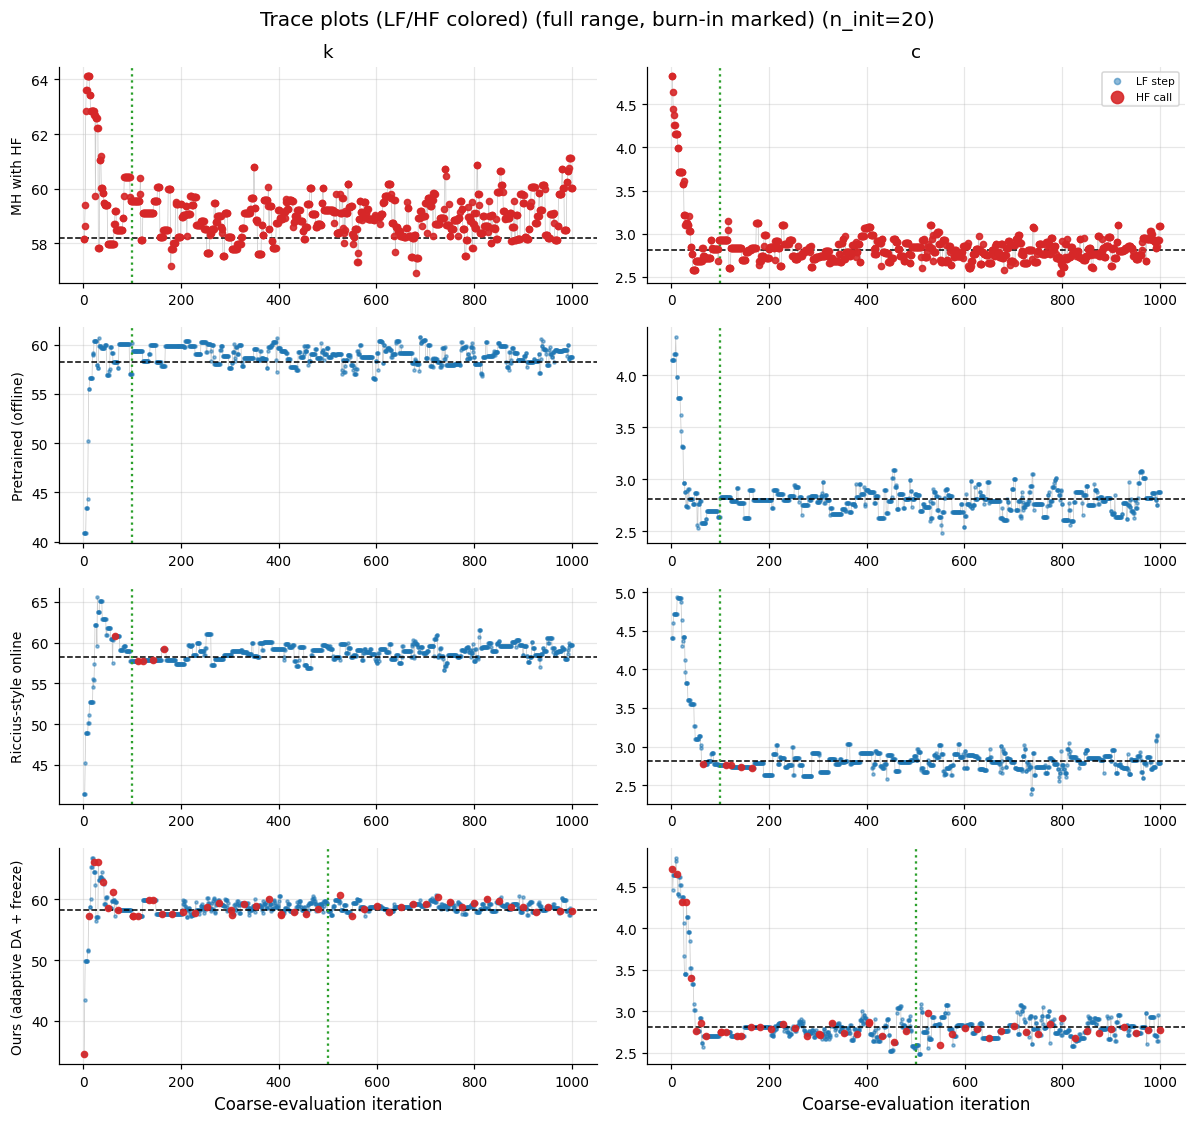

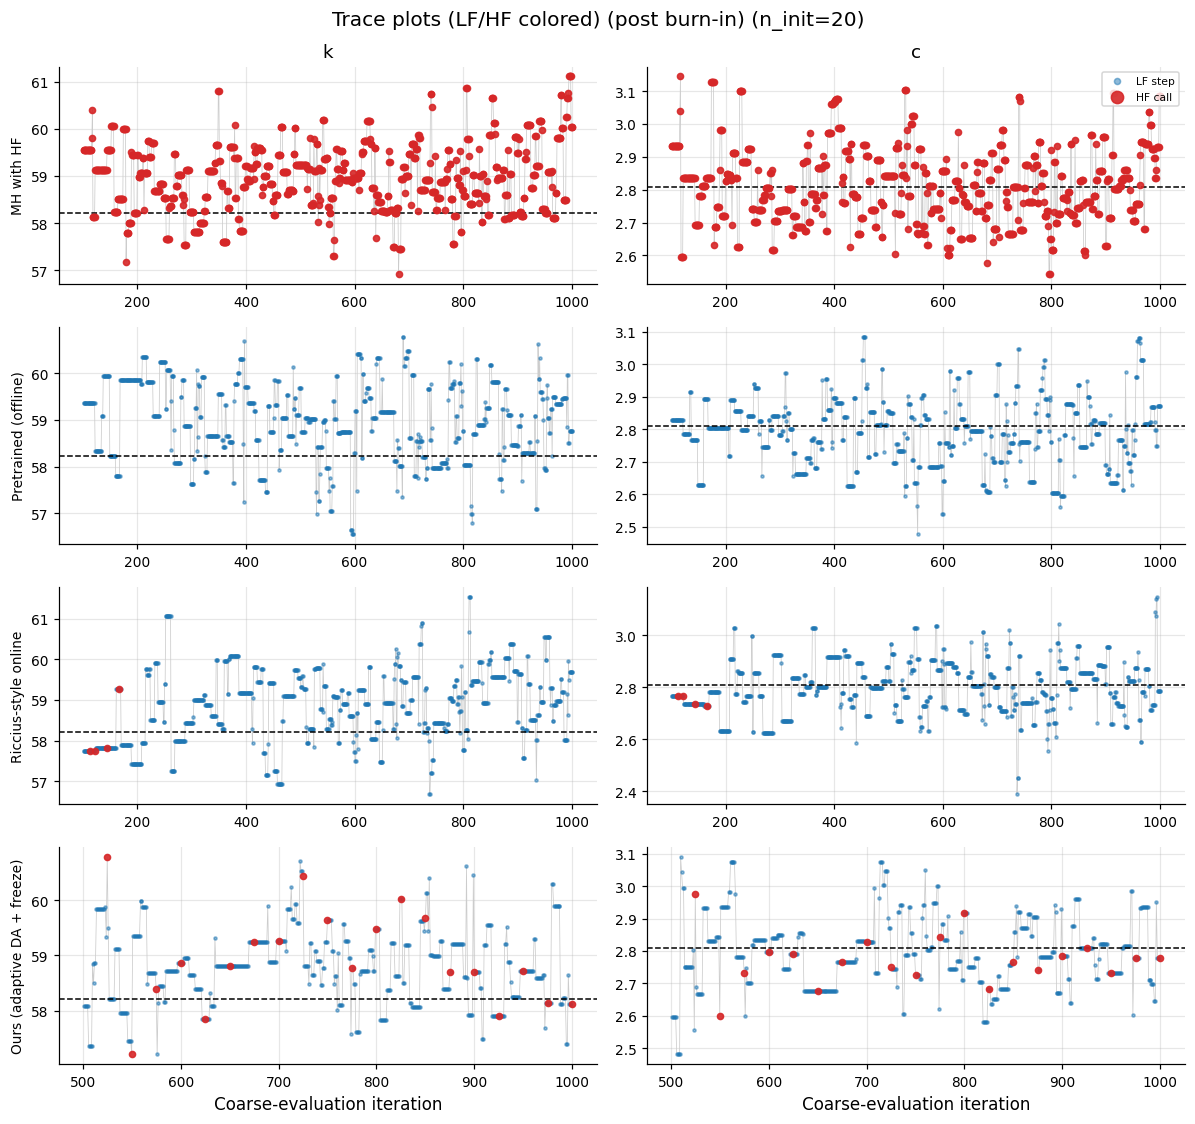

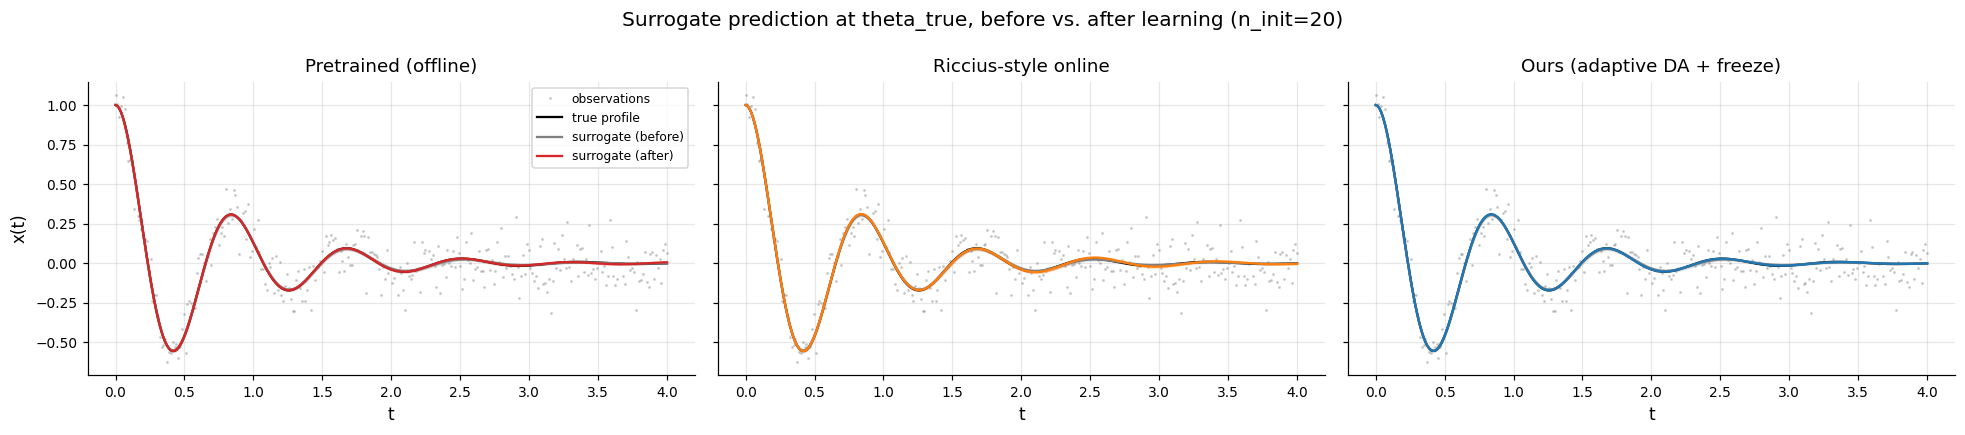

In [5]:
res = run_all_methods(problem, n_init=N_INIT, pod_rank=POD_RANK, seed_offset=N_INIT)
all_results = {N_INIT: res}

print(f"\n--- summary (n_init={N_INIT}) ---")
print_summary_table(problem, N_INIT, res)

trace_chains = {**res["chains"], "hf_only_matched": chain_hf_matched}
burn_ins = {
    "hf_only_matched": BURN_IN,
    "pretrained": BURN_IN,
    "online_active": BURN_IN,
    "ours": effective_burn_in("ours", meta_ours=res["meta_ours"]),
}

fig1 = plot_posterior_comparison(problem, N_INIT, chain_ref, res["chains"], res["meta_ours"])
fig2 = plot_hf_fraction(N_INIT, res["chains"], res["n_hf_pretrained"], res["meta_ours"])
fig3 = make_hf_colored_trace_fig(
    problem, N_INIT, trace_chains, res["meta_ours"], burn_ins, "full", " (full range, burn-in marked)"
)
fig4 = make_hf_colored_trace_fig(
    problem, N_INIT, trace_chains, res["meta_ours"], burn_ins, "post_burn_in", " (post burn-in)"
)
fig5 = plot_surrogate_before_after(problem, N_INIT, res["seed_surrogate"], res["surrogates_after"])

save_fig(fig1, "posterior_comparison", N_INIT)
save_fig(fig2, "hf_fraction", N_INIT)
save_fig(fig3, "trace_full", N_INIT)
save_fig(fig4, "trace_post_burn_in", N_INIT)
save_fig(fig5, "surrogate_before_after", N_INIT)


## 5. Posterior-accuracy comparison (single seed): cost to reach R-hat<=1.01

This is the paper's posterior-accuracy comparison -- `hf_only`, `online_active`, and
**`ours` only**. `pretrained` is deliberately not run here at all (not just hidden from
the plots: `run_convergence_driven_comparison`'s `methods=` argument skips its
replicate loop entirely) -- see cell 44ec13f4's markdown for why a frozen/uncorrected-
vs-DA-corrected posterior comparison wouldn't isolate anything this paper claims.
`pretrained`'s training cost is compared separately, in section 5c.

Rather than a fixed, arbitrarily-chosen iteration budget, this runs each of the three
methods **until its `N_CHAINS` replicate chains agree** (R-hat<=1.01, patience-checked)
**or a safety cap is hit**, and reports the cost -- HF calls, coarse evals, wall-clock
rounds -- to get there, alongside the resulting accuracy. That's the comparison a
reviewer will look for first: it directly compares methods on the resource each is
meant to save, rather than on an arbitrarily shared iteration count.

This single-seed run is a preview of the same computation section 6 aggregates over
25 seeds (`run_sweep_convergence_driven.py`) -- useful for sanity-checking the figures
without waiting for the full sweep, but the seed-to-seed variability shown in section 6
is what the paper's numbers should actually cite.

Implementation notes (see `run_until_rhat_converged`/`run_convergence_driven_comparison`
in `msd_methods.py` for the full detail):

- The `N_CHAINS` replicates are advanced in synchronized rounds, each round's chunk
  run **in parallel** across processes (`joblib`).
- `CONVERGENCE_DRIVEN_CHUNK_SIZE` controls how often R-hat is (re-)checked; smaller
  means finer-grained stopping at the cost of more parallel-dispatch overhead per
  round. `CONVERGENCE_DRIVEN_MAX_TOTAL_COARSE_EVALS` is the safety valve for methods
  that may never converge in the R-hat sense (e.g. `online_active`, whose replicates
  keep learning independently online and can drift to different,
  individually-stable-but-mutually-disagreeing answers -- R-hat correctly never
  resolves in that case, which is itself a meaningful finding, not a bug).
- Expect this cell to take a couple of minutes at the defaults above.



--- convergence-driven comparison (n_init=20, 5 chains, chunk_size=500, cap=10000) ---
--- hf_only: 5 chains ---


  [hf_only] round 1: coarse_evals=500/10000  rhat=(k=1.351, c=1.911)  converged=False


  [hf_only] round 2: coarse_evals=1000/10000  rhat=(k=1.407, c=1.460)  converged=False


  [hf_only] round 3: coarse_evals=1500/10000  rhat=(k=1.235, c=1.385)  converged=False


  [hf_only] round 4: coarse_evals=2000/10000  rhat=(k=1.260, c=1.498)  converged=False


...

  [ours] round 6: coarse_evals=3000/10000  rhat=(k=1.003, c=1.000)  converged=True
--- ours done: converged=True, 6 rounds ---
method            status  rounds  coarse_evals    n_hf    w2_ref    kl_ref      rmse
hf_only        converged       5          2500   12505        --        --    0.8838
online_active  converged       5          2500     110    0.1034    0.0389    0.9729
ours           converged       6          3000     705    0.0172    0.0072    0.8722


  saved results/figures/pooled_posterior_convergence_driven_n_init_20.png
  saved results/figures/hf_fraction_multichain_convergence_driven_n_init_20.png


  saved results/figures/trace_multichain_convergence_driven_full_n_init_20.png


  saved results/figures/trace_multichain_convergence_driven_post_burn_in_n_init_20.png
  saved results/figures/surrogate_multichain_convergence_driven_n_init_20.png


59413

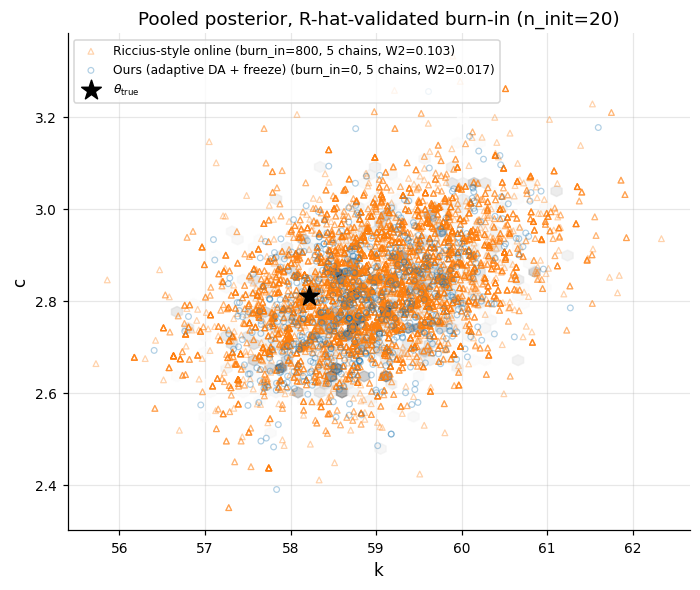

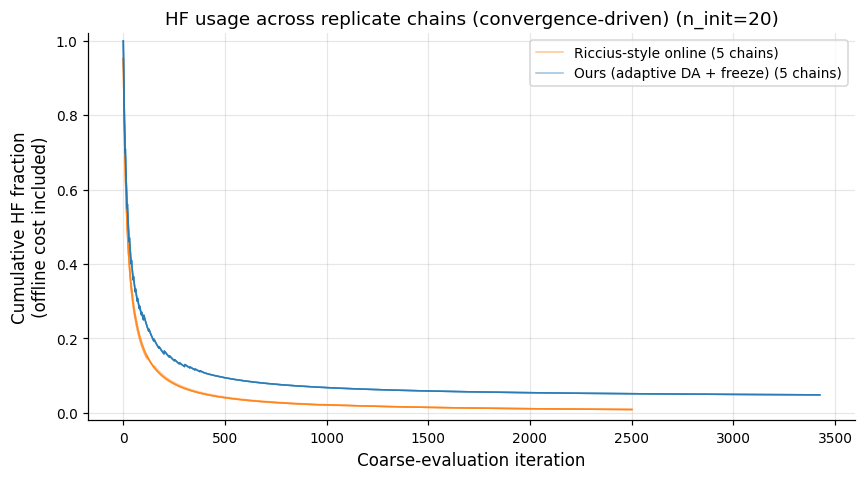

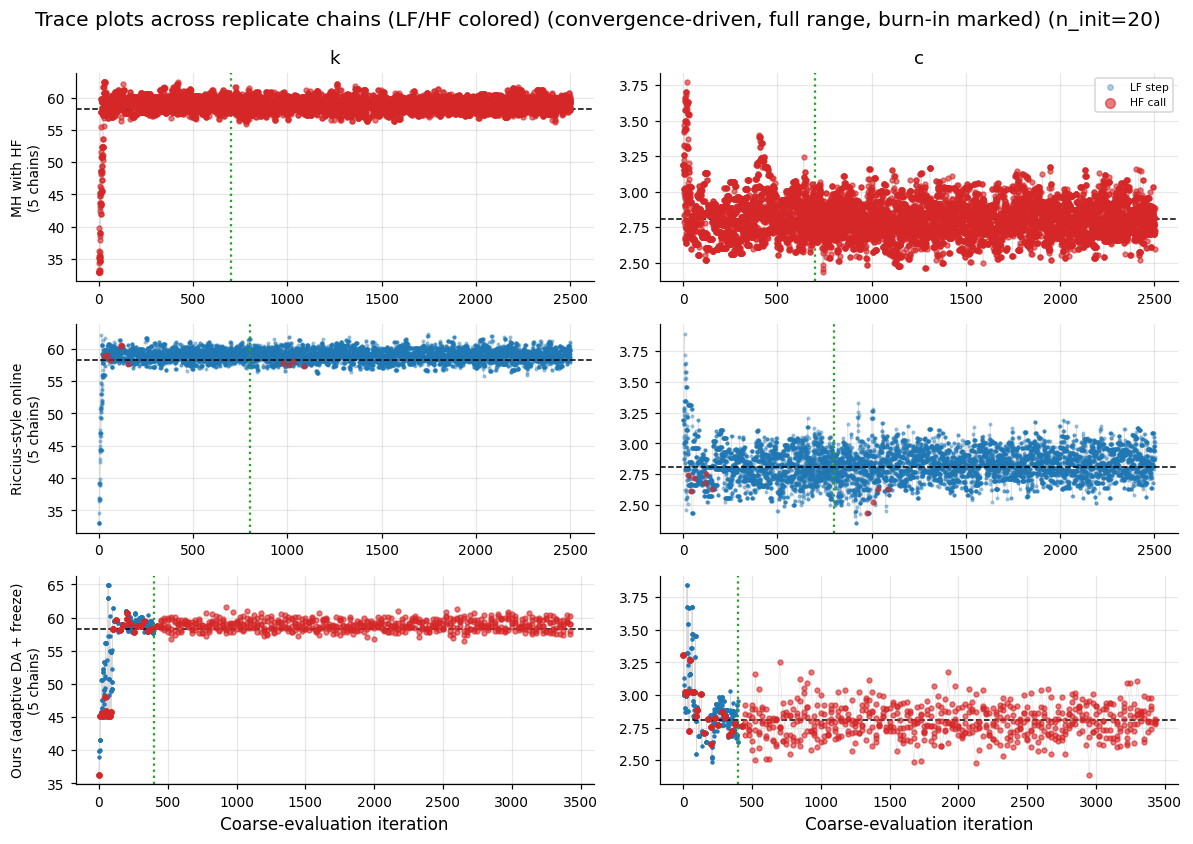

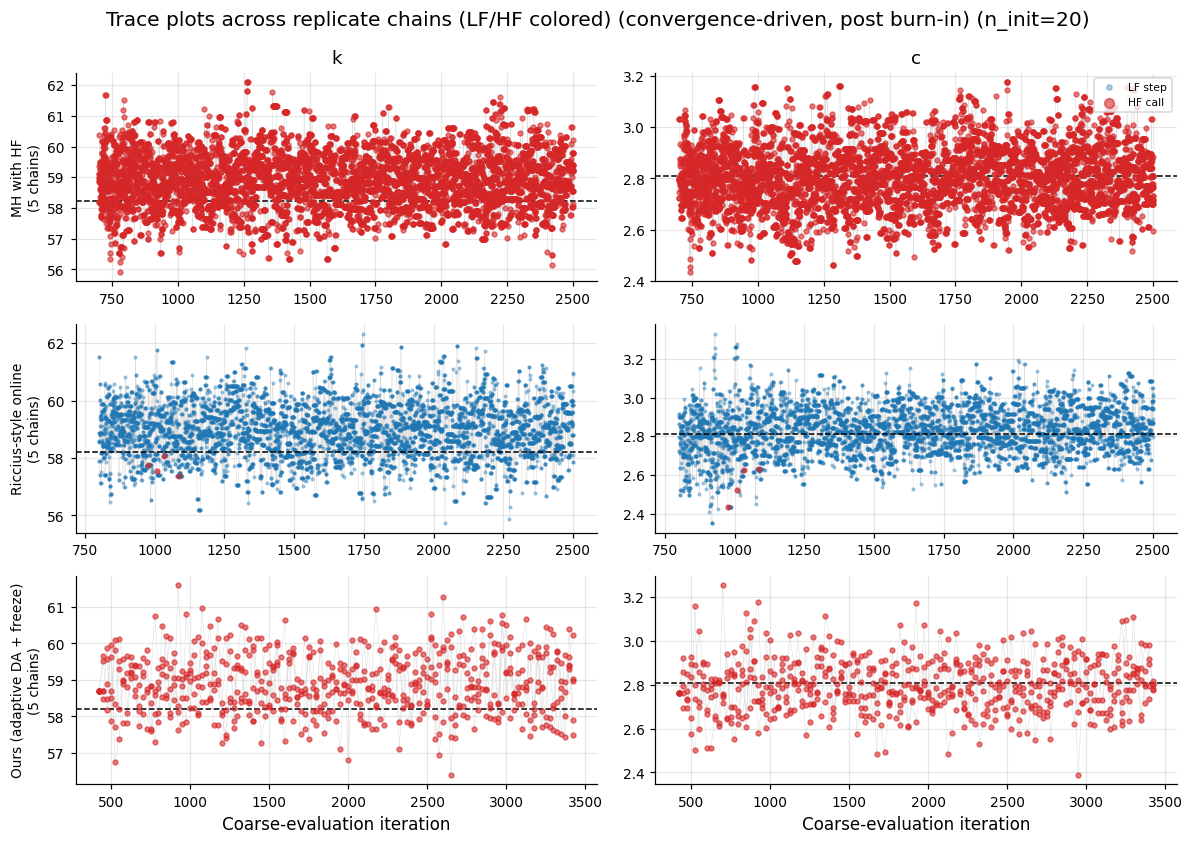

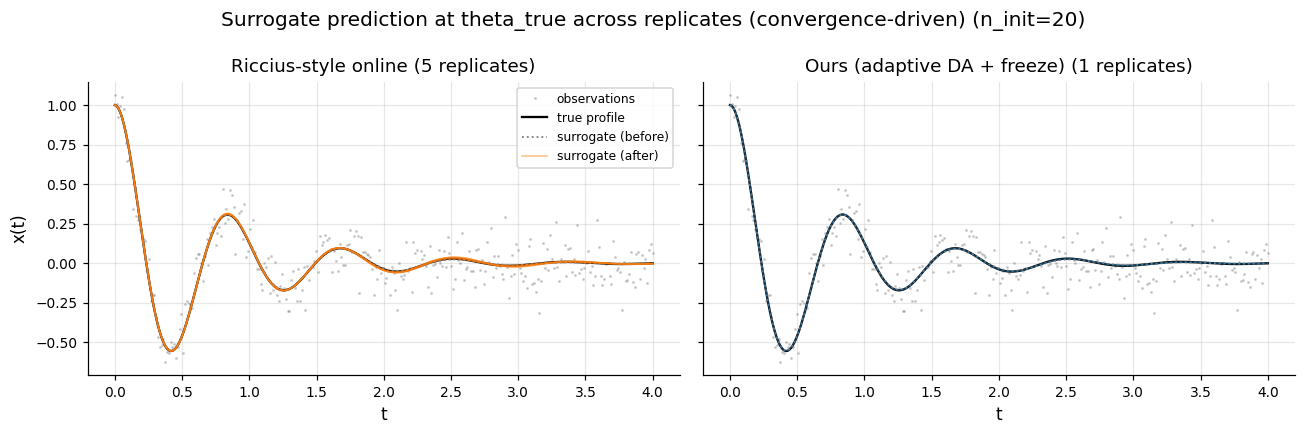

In [6]:
print(f"\n--- convergence-driven comparison (n_init={N_INIT}, {N_CHAINS} chains, "
      f"chunk_size={CONVERGENCE_DRIVEN_CHUNK_SIZE}, cap={CONVERGENCE_DRIVEN_MAX_TOTAL_COARSE_EVALS}) ---")
conv_driven, chains_by_method_driven, surrogates_by_method_driven = run_convergence_driven_comparison(
    problem,
    n_init=N_INIT,
    rhat_threshold=CONVERGENCE_DRIVEN_RHAT_THRESHOLD,
    min_ess=CONVERGENCE_DRIVEN_MIN_ESS,
    pod_rank=POD_RANK,
    seed_X=res["seed_X"],
    seed_Y=res["seed_Y"],
    seed_surrogate=res["seed_surrogate"],
    n_chains=N_CHAINS,
    chunk_size=CONVERGENCE_DRIVEN_CHUNK_SIZE,
    max_total_coarse_evals=CONVERGENCE_DRIVEN_MAX_TOTAL_COARSE_EVALS,
    methods=("hf_only", "online_active", "ours"),  # pretrained excluded -- see cell 44ec13f4's markdown
)
all_convergence_driven = {N_INIT: conv_driven}
print_convergence_driven_table(conv_driven)

fig7 = plot_pooled_posterior_comparison(
    problem, N_INIT, chain_ref, conv_driven, chains_by_method_driven, method_order=METHOD_ORDER_ACCURACY
)

# Multi-chain (all N_CHAINS replicates) versions of section 4's other plot types.
offline_costs_by_method_driven = {name: r["pooled"]["n_offline_hf"] for name, r in conv_driven.items()}
traces5b, burn_ins5b = prepare_multichain_traces_section5b(
    chains_by_method_driven, conv_driven, method_order=METHOD_ORDER_ACCURACY
)
fig11 = plot_hf_fraction_multichain(
    N_INIT, traces5b, offline_costs_by_method_driven, " (convergence-driven)", method_order=METHOD_ORDER_ACCURACY
)
fig12 = make_hf_colored_trace_fig_multichain(
    problem, N_INIT, traces5b, burn_ins5b, "full", " (convergence-driven, full range, burn-in marked)",
    trace_method_order=TRACE_METHOD_ORDER_MULTICHAIN_ACCURACY,
)
fig12b = make_hf_colored_trace_fig_multichain(
    problem, N_INIT, traces5b, burn_ins5b, "post_burn_in", " (convergence-driven, post burn-in)",
    trace_method_order=TRACE_METHOD_ORDER_MULTICHAIN_ACCURACY,
)
fig13 = plot_surrogate_before_after_multichain(
    problem, N_INIT, res["seed_surrogate"], surrogates_by_method_driven, " (convergence-driven)",
    method_order=METHOD_ORDER_ACCURACY,
)

save_fig(fig7, "pooled_posterior_convergence_driven", N_INIT)
save_fig(fig11, "hf_fraction_multichain_convergence_driven", N_INIT)
save_fig(fig12, "trace_multichain_convergence_driven_full", N_INIT)
save_fig(fig12b, "trace_multichain_convergence_driven_post_burn_in", N_INIT)
save_fig(fig13, "surrogate_multichain_convergence_driven", N_INIT)

(RESULTS_DIR / "notebook_convergence_driven_single_seed.json").write_text(
    json.dumps(all_convergence_driven, indent=2)
)


## 5c. Training-cost comparison (single seed): online vs. offline active learning

This is the comparison that isolates *training strategy* -- see cell 44ec13f4's
markdown for why it's kept separate from the posterior-accuracy comparison above.
`run_training_cost_comparison` runs, from the same shared `N_INIT`-sized seed design:

- `ours`'s online adaptive phase (MCMC-path-guided: only needs to be accurate where
  the posterior actually lives), and
- `pretrained`'s offline active-learning procedure (`active_learning_offline_design`:
  global greedy max-variance acquisition, needs to be accurate everywhere the prior
  has support),

each run *only* to its own convergence criterion, with no downstream MCMC production
phase on either side -- so the reported cost (HF calls beyond the shared seed design,
wall-clock) is training cost alone, not conflated with posterior correction.

Single-seed preview again; section 6 aggregates this over 25 seeds.


 /Users/filippozacchei/COde/MFDA_ActiveLearning/.venv/lib/python3.10/site-packages/tinyDA/sampler.py:114: UserWarning: subsampling_rate has been deprecated in favour of subchain_length.


Sampling chain 1/1



  0%|          | 0/10 [00:00<?, ?it/s]


Running chain, α_c = 1.000, α_f = 1.00:   0%|          | 0/10 [00:00<?, ?it/s]


Running chain, α_c = 1.000, α_f = 1.00:  10%|█         | 1/10 [00:00<00:05,  1.63it/s]

...


Running chain, α_c = 0.433, α_f = 1.00:  92%|█████████▏| 11/12 [00:02<00:00,  5.27it/s]


Running chain, α_c = 0.429, α_f = 1.00:  92%|█████████▏| 11/12 [00:02<00:00,  5.27it/s]


Running chain, α_c = 0.429, α_f = 1.00: 100%|██████████| 12/12 [00:03<00:00,  5.15it/s]


Running chain, α_c = 0.429, α_f = 1.00: 100%|██████████| 12/12 [00:03<00:00,  3.99it/s]

offline (pretrained-style):   50 extra HF calls beyond the shared n_init=20 design  (70 total)  wall_time=19.4s
online  (ours' adaptive phase):   40 extra HF calls  (400 coarse-eval units)  converged=True  final_subchain_length=25  wall_time=22.4s
  saved results/figures/training_cost_single_seed_n_init_20.png
  saved results/figures/subchain_length_adaptation_single_seed_n_init_20.png


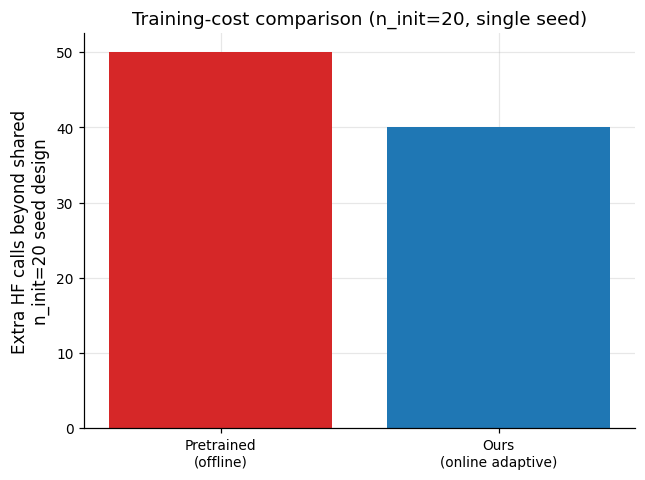

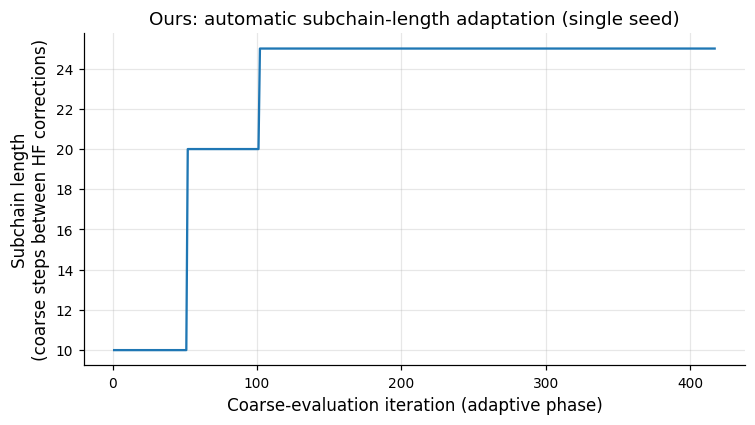

In [7]:
training_cost = run_training_cost_comparison(
    problem,
    seed_X=res["seed_X"],
    seed_Y=res["seed_Y"],
    seed_surrogate=res["seed_surrogate"],
    gamma_threshold=GAMMA_THRESHOLD,
    pod_rank=POD_RANK,
    max_adapt_coarse_evals=MAX_ADAPT_COARSE_EVALS,
    seed_base=90_000,
)
(RESULTS_DIR / "notebook_training_cost_single_seed.json").write_text(json.dumps(training_cost, indent=2))

offline, online = training_cost["offline"], training_cost["online"]
print(f"offline (pretrained-style): {offline['n_hf_extra']:>4} extra HF calls beyond the shared "
      f"n_init={training_cost['n_init']} design  ({offline['n_hf_total']} total)  "
      f"wall_time={offline['wall_time_s']:.1f}s")
print(f"online  (ours' adaptive phase): {online['n_hf_extra']:>4} extra HF calls  "
      f"({online['coarse_evals_used']} coarse-eval units)  converged={online['converged']}  "
      f"final_subchain_length={online['final_subchain_length']}  wall_time={online['wall_time_s']:.1f}s")

fig14, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(
    ["Pretrained\n(offline)", "Ours\n(online adaptive)"],
    [offline["n_hf_extra"], online["n_hf_extra"]],
    color=[METHOD_COLORS["pretrained"], METHOD_COLORS["ours"]],
)
ax.set_ylabel(f"Extra HF calls beyond shared\nn_init={training_cost['n_init']} seed design")
ax.set_title(f"Training-cost comparison (n_init={N_INIT}, single seed)")
fig14.tight_layout()
save_fig(fig14, "training_cost_single_seed", N_INIT)

fig15, ax = plt.subplots(figsize=(7, 4))
subchain_hist = online["subchain_length_history"]
if subchain_hist:
    ax.plot(np.arange(1, len(subchain_hist) + 1), subchain_hist, color=METHOD_COLORS["ours"], lw=1.5)
    ax.set_xlabel("Coarse-evaluation iteration (adaptive phase)")
    ax.set_ylabel("Subchain length\n(coarse steps between HF corrections)")
    ax.set_title("Ours: automatic subchain-length adaptation (single seed)")
    fig15.tight_layout()
    save_fig(fig15, "subchain_length_adaptation_single_seed", N_INIT)


## 6. Multi-seed results (the paper's actual numbers): 25-seed sweep

Sections 4/5/5c above are each a single problem instance/seed -- useful for
sanity-checking the figures, but the paper's accuracy/cost/robustness claims should be
based on the multi-seed sweep, produced by `run_sweep_convergence_driven.py` (slow --
run separately, in the background:
`python run_sweep_convergence_driven.py --n-seeds 25`). For each of the 25 independent
problem instances (fresh `theta_true`/`y_obs` and a freshly-drawn `N_INIT`-sized
offline seed design each), it computes both comparisons from sections 5/5c:
the training-cost comparison (`ours`'s adaptive phase vs. `pretrained`'s offline
active-learning procedure) and the posterior-accuracy comparison (`hf_only`/
`online_active`/`ours`, `pretrained` excluded -- see cell 44ec13f4's markdown).

This cell loads `results/sweep_convergence_driven.jsonl` and aggregates it if it has
already been run (partially or fully -- the sweep script appends one line per seed as
it goes, so a still-running sweep's partial results are already usable here).


Loaded 25 completed seed(s) from /Users/filippozacchei/COde/MFDA_ActiveLearning/examples/toy_problem/results/sweep_convergence_driven.jsonl

=== Training-cost comparison (aggregated over 25 seeds) ===
        offline_n_hf_extra  online_n_hf_extra
mean             63.000000          43.000000
median           75.000000          42.000000
std              19.257033           3.674235

online (ours) adaptive-phase convergence rate: 100.0% (25/25)
  saved results/figures/training_cost_sweep_n_init_20.png

=== Posterior-accuracy comparison (aggregated over 25 seeds) ===
method
hf_only          1.00
online_active    0.72
ours             1.00
Name: convergence_rate, dtype: float64

              total_coarse_evals                      n_hf_calls          \
                            mean  median          std       mean  median   
method                                                                     
hf_only                   1720.0  1500.0   384.057287     8605.0  7505.0   
online_acti

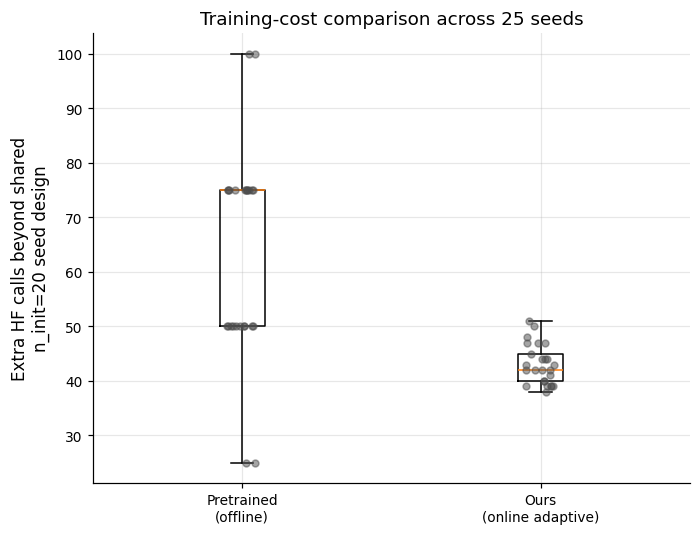

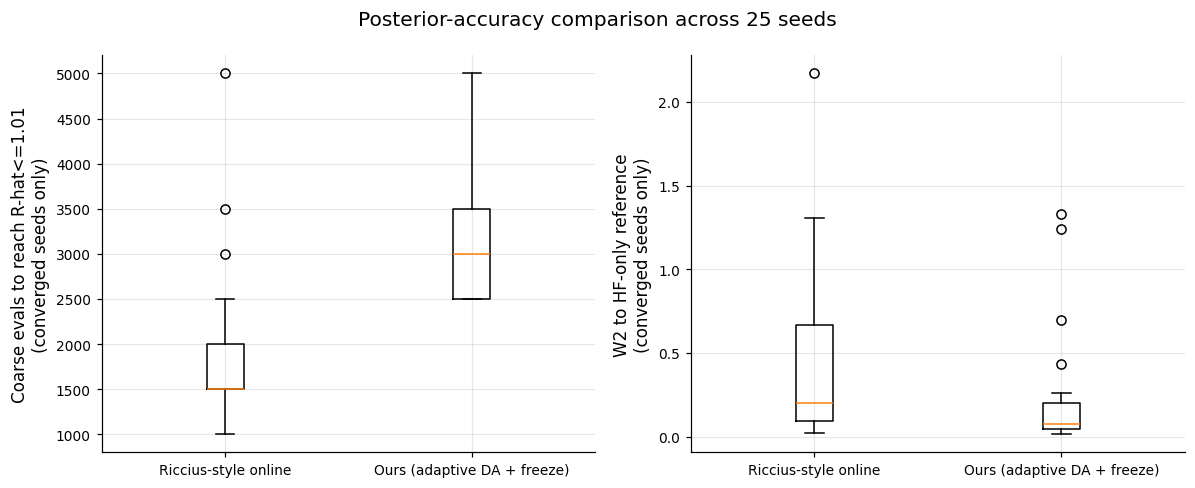

In [8]:
import pandas as pd

sweep_jsonl_path = RESULTS_DIR / "sweep_convergence_driven.jsonl"

if not sweep_jsonl_path.exists():
    print(
        f"{sweep_jsonl_path} not found yet -- run "
        "`python run_sweep_convergence_driven.py --n-seeds 25` (in the background; "
        "it takes roughly 1-1.5h at the defaults) to generate the sweep, then "
        "re-run this cell. Partial results (from a still-running sweep) are used as "
        "soon as at least one seed has completed."
    )
else:
    sweep_rows = [json.loads(line) for line in sweep_jsonl_path.read_text().splitlines() if line.strip()]
    print(f"Loaded {len(sweep_rows)} completed seed(s) from {sweep_jsonl_path}")

    if sweep_rows:
        # --- Training-cost comparison, aggregated ---------------------------------
        tc_df = pd.DataFrame([
            {
                "seed": r["seed"],
                "offline_n_hf_extra": r["training_cost"]["offline"]["n_hf_extra"],
                "offline_wall_time_s": r["training_cost"]["offline"]["wall_time_s"],
                "online_n_hf_extra": r["training_cost"]["online"]["n_hf_extra"],
                "online_coarse_evals_used": r["training_cost"]["online"]["coarse_evals_used"],
                "online_wall_time_s": r["training_cost"]["online"]["wall_time_s"],
                "online_converged": r["training_cost"]["online"]["converged"],
            }
            for r in sweep_rows
        ])
        print("\n=== Training-cost comparison (aggregated over", len(tc_df), "seeds) ===")
        print(tc_df[["offline_n_hf_extra", "online_n_hf_extra"]].agg(["mean", "median", "std"]))
        print(f"\nonline (ours) adaptive-phase convergence rate: "
              f"{tc_df['online_converged'].mean():.1%} ({tc_df['online_converged'].sum()}/{len(tc_df)})")

        fig16, ax = plt.subplots(figsize=(6.5, 5))
        ax.boxplot(
            [tc_df["offline_n_hf_extra"], tc_df["online_n_hf_extra"]],
            tick_labels=["Pretrained\n(offline)", "Ours\n(online adaptive)"],
        )
        for i, col in enumerate(["offline_n_hf_extra", "online_n_hf_extra"], start=1):
            ax.scatter(np.full(len(tc_df), i) + np.random.default_rng(0).uniform(-0.05, 0.05, len(tc_df)),
                       tc_df[col], alpha=0.5, s=20, color="0.3", zorder=3)
        ax.set_ylabel(f"Extra HF calls beyond shared\nn_init={N_INIT} seed design")
        ax.set_title(f"Training-cost comparison across {len(tc_df)} seeds")
        fig16.tight_layout()
        save_fig(fig16, "training_cost_sweep", N_INIT)

        # --- Posterior-accuracy comparison, aggregated -----------------------------
        pa_rows = []
        for r in sweep_rows:
            for method in ("hf_only", "online_active", "ours"):
                p = r["posterior"][method]
                pooled = p.get("pooled", {})
                pa_rows.append({
                    "seed": r["seed"],
                    "method": method,
                    "converged": p["converged"],
                    "rounds_run": p["rounds_run"],
                    "total_coarse_evals": p["total_coarse_evals"],
                    "n_hf_calls": pooled.get("n_hf_calls"),
                    "w2_ref": pooled.get("wasserstein2_to_reference"),
                    "kl_ref": pooled.get("kl_to_reference"),
                    "rmse": pooled.get("rmse_to_truth"),
                })
        pa_df = pd.DataFrame(pa_rows)
        print("\n=== Posterior-accuracy comparison (aggregated over", len(sweep_rows), "seeds) ===")
        print(pa_df.groupby("method")["converged"].mean().rename("convergence_rate"))
        print()
        print(pa_df.groupby("method")[["total_coarse_evals", "n_hf_calls", "w2_ref", "kl_ref", "rmse"]]
              .agg(["mean", "median", "std"]))

        fig17, axes = plt.subplots(1, 2, figsize=(11, 4.5))
        method_order_pa = ("online_active", "ours")
        converged_df = pa_df[pa_df["converged"]]
        axes[0].boxplot(
            [converged_df[converged_df["method"] == m]["total_coarse_evals"] for m in method_order_pa],
            tick_labels=[METHOD_LABELS[m] for m in method_order_pa],
        )
        axes[0].set_ylabel("Coarse evals to reach R-hat<=1.01\n(converged seeds only)")
        axes[1].boxplot(
            [converged_df[converged_df["method"] == m]["w2_ref"].dropna() for m in method_order_pa],
            tick_labels=[METHOD_LABELS[m] for m in method_order_pa],
        )
        axes[1].set_ylabel("W2 to HF-only reference\n(converged seeds only)")
        fig17.suptitle(f"Posterior-accuracy comparison across {len(sweep_rows)} seeds")
        fig17.tight_layout()
        save_fig(fig17, "posterior_accuracy_sweep", N_INIT)
